# AF Database (AFDB) Analysis

This notebook provides a comprehensive analysis of the MIT-BIH Atrial Fibrillation Database (AFDB), including all rhythm types present in the dataset.

In [1]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import wfdb
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Local data path ───────────────────────────────────────────────────────────
DATA_DIR = r'C:/Users/Admin/OneDrive/Skrivebord/Afib-Master/data/MIT-BIH AFDB/files'

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

## 1. Load All Records and Extract Metadata

In [2]:
# Discover all records in the local data directory.
# A record is identified by the presence of a .hea header file.
record_list = sorted([
    os.path.splitext(f)[0]
    for f in os.listdir(DATA_DIR)
    if f.endswith('.hea')
])
print(f"Total number of records found: {len(record_list)}")
print(f"\nRecord names: {record_list}")

Total number of records found: 25

Record names: ['00735', '03665', '04015', '04043', '04048', '04126', '04746', '04908', '04936', '05091', '05121', '05261', '06426', '06453', '06995', '07162', '07859', '07879', '07910', '08215', '08219', '08378', '08405', '08434', '08455']


In [3]:
# Analyze each record and collect metadata
record_data = []

print("Analyzing all records...\n")
print("="*80)

for idx, record_name in enumerate(record_list, 1):
    try:
        record = wfdb.rdrecord(os.path.join(DATA_DIR, record_name))

        duration_seconds = len(record.p_signal) / record.fs
        duration_minutes = duration_seconds / 60
        duration_hours = duration_minutes / 60

        record_data.append({
            'Record': record_name,
            'Duration (min)': round(duration_minutes, 2),
            'Duration (hours)': round(duration_hours, 3),
            'Sampling Rate (Hz)': record.fs,
            'Channels': len(record.sig_name)
        })

        print(f"{idx}. {record_name}:")
        print(f"   Duration: {duration_hours:.2f} hours ({duration_minutes:.1f} min)")
        print(f"   Sampling rate: {record.fs} Hz")
        print(f"   Channels: {len(record.sig_name)}")
        print()

    except Exception as e:
        print(f"Error processing {record_name}: {e}\n")

print("="*80)
df_records = pd.DataFrame(record_data)

Analyzing all records...

Error processing 00735: sampto must be greater than sampfrom

Error processing 03665: sampto must be greater than sampfrom

3. 04015:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

4. 04043:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

5. 04048:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

6. 04126:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

7. 04746:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

8. 04908:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

9. 04936:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

10. 05091:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

11. 05121:
   Duration: 10.23 hours (613.7 min)
   Sampling rate: 250 Hz
   Channels: 2

12. 05261:
   Duration: 10.23 hours (613.7 min)
   Sampl

---
## Table 1: Dataset Overview

In [4]:
# Compute summary statistics
total_records      = len(df_records)
total_dur_hrs      = df_records['Duration (hours)'].sum()
min_dur            = df_records['Duration (hours)'].min()
max_dur            = df_records['Duration (hours)'].max()
mean_dur           = df_records['Duration (hours)'].mean()
fs_value           = df_records['Sampling Rate (Hz)'].iloc[0]   # same for all
n_channels         = df_records['Channels'].iloc[0]             # same for all

overview = pd.DataFrame({
    'Metric': [
        'Number of Recordings',
        'Duration per Recording (min range)',
        'Average Duration per Recording (hours)',
        'Sampling Frequency (Hz)',
        'Number of Channels',
        'Total Duration (hours)'
    ],
    'Value': [
        total_records,
        f"{df_records['Duration (min)'].min():.1f} – {df_records['Duration (min)'].max():.1f} min",
        f"{mean_dur:.2f} h",
        fs_value,
        n_channels,
        f"{total_dur_hrs:.2f} h"
    ]
})

print("\n" + "="*60)
print("TABLE 1: DATASET OVERVIEW")
print("="*60)
print(overview.to_string(index=False))
print("="*60)


TABLE 1: DATASET OVERVIEW
                                Metric             Value
                  Number of Recordings                23
    Duration per Recording (min range) 555.0 – 613.7 min
Average Duration per Recording (hours)           10.19 h
               Sampling Frequency (Hz)               250
                    Number of Channels                 2
                Total Duration (hours)          234.29 h


---
## 2. Extract Rhythm Annotations Across All Records

In [ ]:
# The four official AFDB rhythm labels as described in the dataset documentation.
# Any annotation code NOT in this set is treated as '(N' (all other rhythms).
RHYTHM_LABELS = {
    '(AFIB': 'Atrial Fibrillation',
    '(AFL':  'Atrial Flutter',
    '(J':    'AV Junctional Rhythm',
    '(N':    'Normal Rhythm (other)',
}

# Maintain a fixed display order
RHYTHM_ORDER = ['(AFIB', '(AFL', '(J', '(N']

# Collect rhythm segments from ALL records
rhythm_counts   = {code: 0 for code in RHYTHM_ORDER}
rhythm_examples = {}   # code -> (record_name, sample_start, fs)

print("Reading annotations from all records...")

for record_name in record_list:
    try:
        ann    = wfdb.rdann(os.path.join(DATA_DIR, record_name), 'atr')
        record = wfdb.rdrecord(os.path.join(DATA_DIR, record_name))

        for i, aux in enumerate(ann.aux_note):
            if aux:
                raw_code = aux.strip().rstrip('\x00')
                # Map to one of the four official codes; anything else → '(N'
                code = raw_code if raw_code in RHYTHM_LABELS else '(N'
                rhythm_counts[code] += 1

                # Store first example per rhythm type for the ECG plot
                if code not in rhythm_examples:
                    rhythm_examples[code] = (record_name, ann.sample[i], record.fs)

    except Exception as e:
        print(f"  Warning – could not read annotations for {record_name}: {e}")

print("\nDone. Segment counts per rhythm:")
for code in RHYTHM_ORDER:
    print(f"  {code:8s}  ({RHYTHM_LABELS[code]})  →  {rhythm_counts[code]} segments")

Reading annotations from all records...
  Warning – could not read annotations for 00735: sampto must be greater than sampfrom
  Warning – could not read annotations for 03665: sampto must be greater than sampfrom

Done. Segment counts per rhythm:
  (AFIB     (Atrial Fibrillation)  →  291 segments
  (AFL      (Atrial Flutter)  →  14 segments
  (J        (AV Junctional Rhythm)  →  12 segments
  (N        (Normal Rhythm (other))  →  288 segments


---
## Table 2: Class Distribution

In [6]:
total_segments = sum(rhythm_counts.values())

dist_rows = []
for code in RHYTHM_ORDER:
    cnt   = rhythm_counts[code]
    label = RHYTHM_LABELS[code]
    pct   = 100.0 * cnt / total_segments if total_segments > 0 else 0
    dist_rows.append({
        'Rhythm Code':    code,
        'Rhythm Name':    label,
        'Segments':       cnt,
        'Percentage (%)': f"{pct:.2f}%"
    })

dist_rows.append({
    'Rhythm Code':    'TOTAL',
    'Rhythm Name':    '',
    'Segments':       total_segments,
    'Percentage (%)': '100.00%'
})

df_dist = pd.DataFrame(dist_rows)

print("\n" + "="*75)
print("TABLE 2: CLASS DISTRIBUTION")
print("="*75)
print(df_dist.to_string(index=False))
print("="*75)


TABLE 2: CLASS DISTRIBUTION
Rhythm Code           Rhythm Name  Segments Percentage (%)
      (AFIB   Atrial Fibrillation       291         48.10%
       (AFL        Atrial Flutter        14          2.31%
         (J  AV Junctional Rhythm        12          1.98%
         (N Normal Rhythm (other)       288         47.60%
      TOTAL                             605        100.00%


---
## Pie Chart: Class Distribution

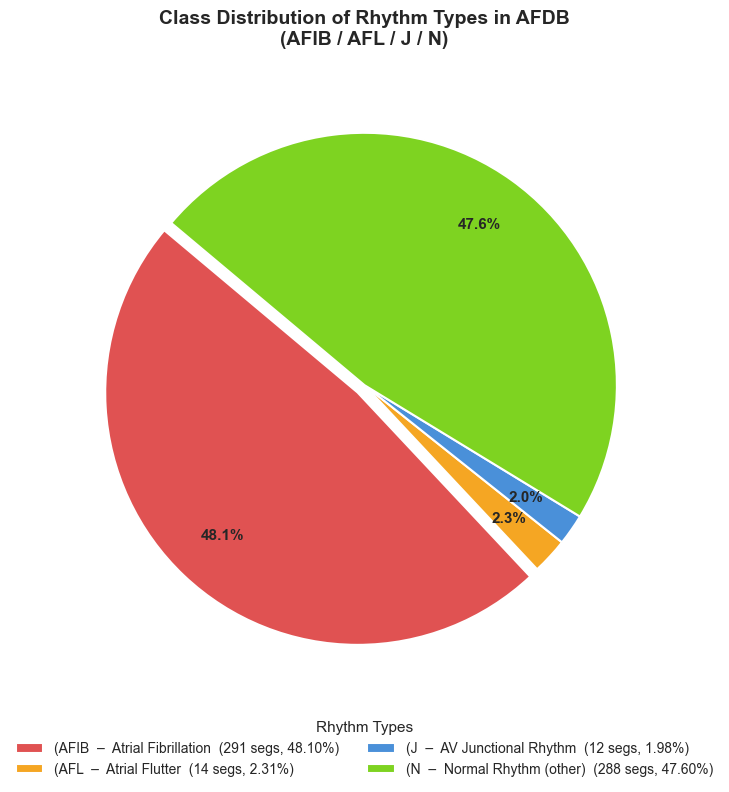

Pie chart saved to class_distribution_pie.png


In [7]:
# Prepare data (exclude TOTAL row)
df_pie = df_dist[df_dist['Rhythm Code'] != 'TOTAL'].copy()
labels  = [f"{row['Rhythm Code']}\n{row['Rhythm Name']}" for _, row in df_pie.iterrows()]
sizes   = df_pie['Segments'].values

# Fixed colors for the four official rhythms
colors = ['#e05252', '#f5a623', '#4a90d9', '#7ed321']

# Explode the largest slice slightly
explode = [0.04 if i == 0 else 0 for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(11, 8))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
    startangle=140,
    colors=colors,
    explode=explode,
    pctdistance=0.78,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

# Legend outside pie
legend_labels = [
    f"{row['Rhythm Code']}  –  {row['Rhythm Name']}  ({row['Segments']} segs, {row['Percentage (%)']})"
    for _, row in df_pie.iterrows()
]
ax.legend(
    wedges, legend_labels,
    title='Rhythm Types',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    fontsize=10,
    title_fontsize=11,
    framealpha=0.8
)

ax.set_title(
    'Class Distribution of Rhythm Types in AFDB\n(AFIB / AFL / J / N)',
    fontsize=14, fontweight='bold', pad=18
)
plt.tight_layout()
plt.savefig('class_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pie chart saved to class_distribution_pie.png")

---
## ECG Segments: Normal Sinus Rhythm vs. Atrial Fibrillation

In [10]:
from scipy.signal import butter, filtfilt

def highpass_filter(signal, fs, cutoff=0.5):
    b, a = butter(N=3, Wn=cutoff / (fs / 2), btype='high')
    return filtfilt(b, a, signal)


def plot_ecg_segment(record_name, sample_start, fs, rhythm_code, rhythm_name,
                     duration_sec=10, channel=0, ax=None, color='steelblue'):
    n_samples  = int(duration_sec * fs)
    sample_end = sample_start + n_samples

    record = wfdb.rdrecord(
        os.path.join(DATA_DIR, record_name),
        sampfrom=sample_start,
        sampto=sample_end,
        channels=[channel]
    )

    signal = record.p_signal[:, 0]          # physical units (mV)
    signal = highpass_filter(signal, fs)    # remove baseline wander  ← NEW
    t      = np.arange(len(signal)) / fs    # time axis in seconds


    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 3))

    ax.plot(t, signal, color=color, linewidth=0.9)
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Amplitude (mV)', fontsize=11)
    ax.set_title(
        f'ECG Segment — {rhythm_name}  [{rhythm_code}]\n'
        f'Record: {record_name}  |  Lead: {record.sig_name[0]}  |  '
        f'Duration: {duration_sec} s  |  Fs: {fs} Hz',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlim([0, duration_sec])
    ax.grid(True, alpha=0.3)
    return ax


# ── Identify example records for (N) and (AFIB) ──────────────────────────────
# Prefer an occurrence that is at least 5 s from the start of the file
# so we don't accidentally read before sample 0.

DESIRED = ['(N', '(AFIB']
COLORS  = {'(N': 'steelblue', '(AFIB': 'crimson'}
NAMES   = {'(N': 'Normal Sinus Rhythm', '(AFIB': 'Atrial Fibrillation'}

selected = {}   # code -> (record_name, sample_start, fs)

SEGMENT_SEC  = 10     # seconds to display
MARGIN_SAMP  = 250    # start reading 1 s after annotation marker

for code in DESIRED:
    if code in rhythm_examples:
        rec_name, samp, fs_val = rhythm_examples[code]
        # Add a small margin so the segment is clearly within the rhythm
        selected[code] = (rec_name, samp + MARGIN_SAMP, fs_val)
    else:
        print(f"WARNING: rhythm {code} not found in any record.")

print("Selected segments:")
for code, (rec, samp, fs_val) in selected.items():
    print(f"  {code:8s}  record={rec}  start_sample={samp}  fs={fs_val} Hz")

Selected segments:
  (N        record=04015  start_sample=280  fs=250 Hz
  (AFIB     record=04015  start_sample=102834  fs=250 Hz


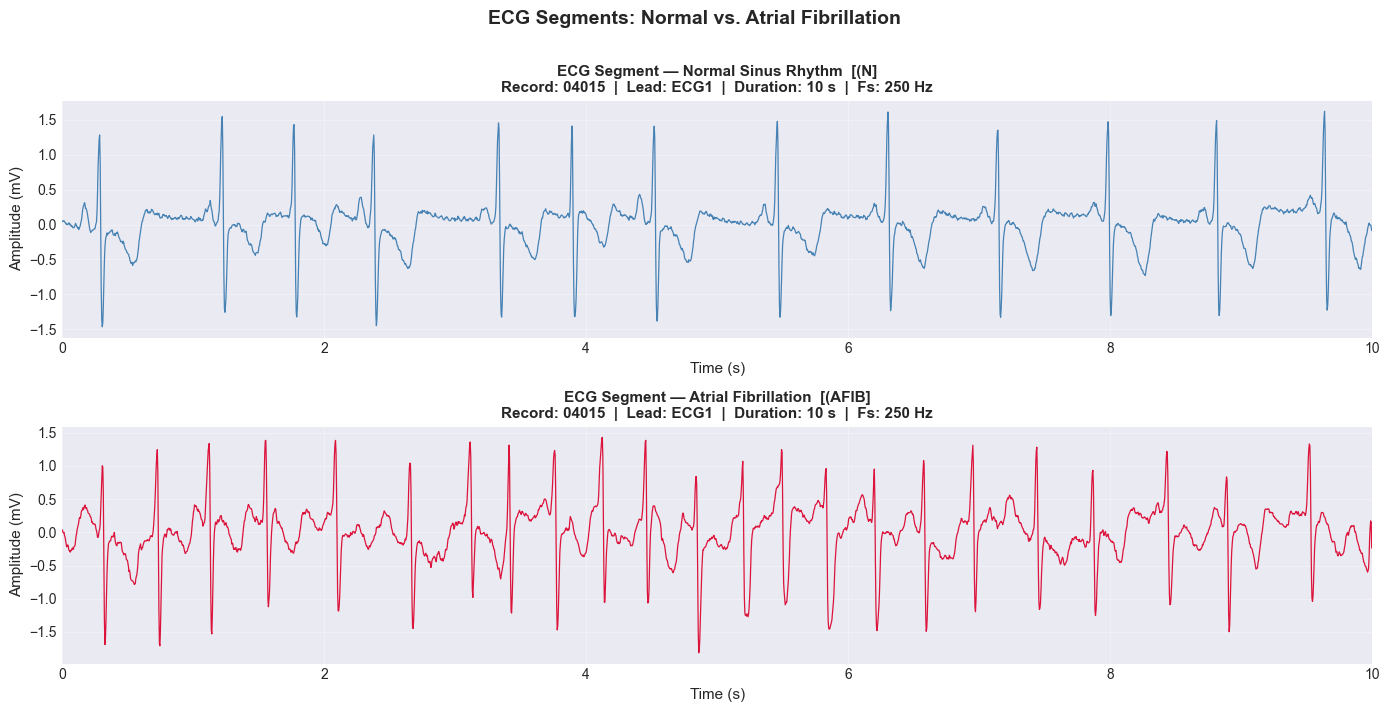

ECG segment plot saved to ecg_segments_N_vs_AFIB.png


In [11]:
# Plot both ECG segments in one figure (stacked)
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('ECG Segments: Normal vs. Atrial Fibrillation', fontsize=14, fontweight='bold', y=1.01)

for ax, code in zip(axes, DESIRED):
    if code in selected:
        rec_name, samp, fs_val = selected[code]
        plot_ecg_segment(
            rec_name, samp, fs_val,
            rhythm_code=code,
            rhythm_name=NAMES[code],
            duration_sec=SEGMENT_SEC,
            channel=0,
            ax=ax,
            color=COLORS[code]
        )
    else:
        ax.text(0.5, 0.5, f'No example found for {code}',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(NAMES.get(code, code))

plt.tight_layout()
plt.savefig('ecg_segments_N_vs_AFIB.png', dpi=150, bbox_inches='tight')
plt.show()
print("ECG segment plot saved to ecg_segments_N_vs_AFIB.png")

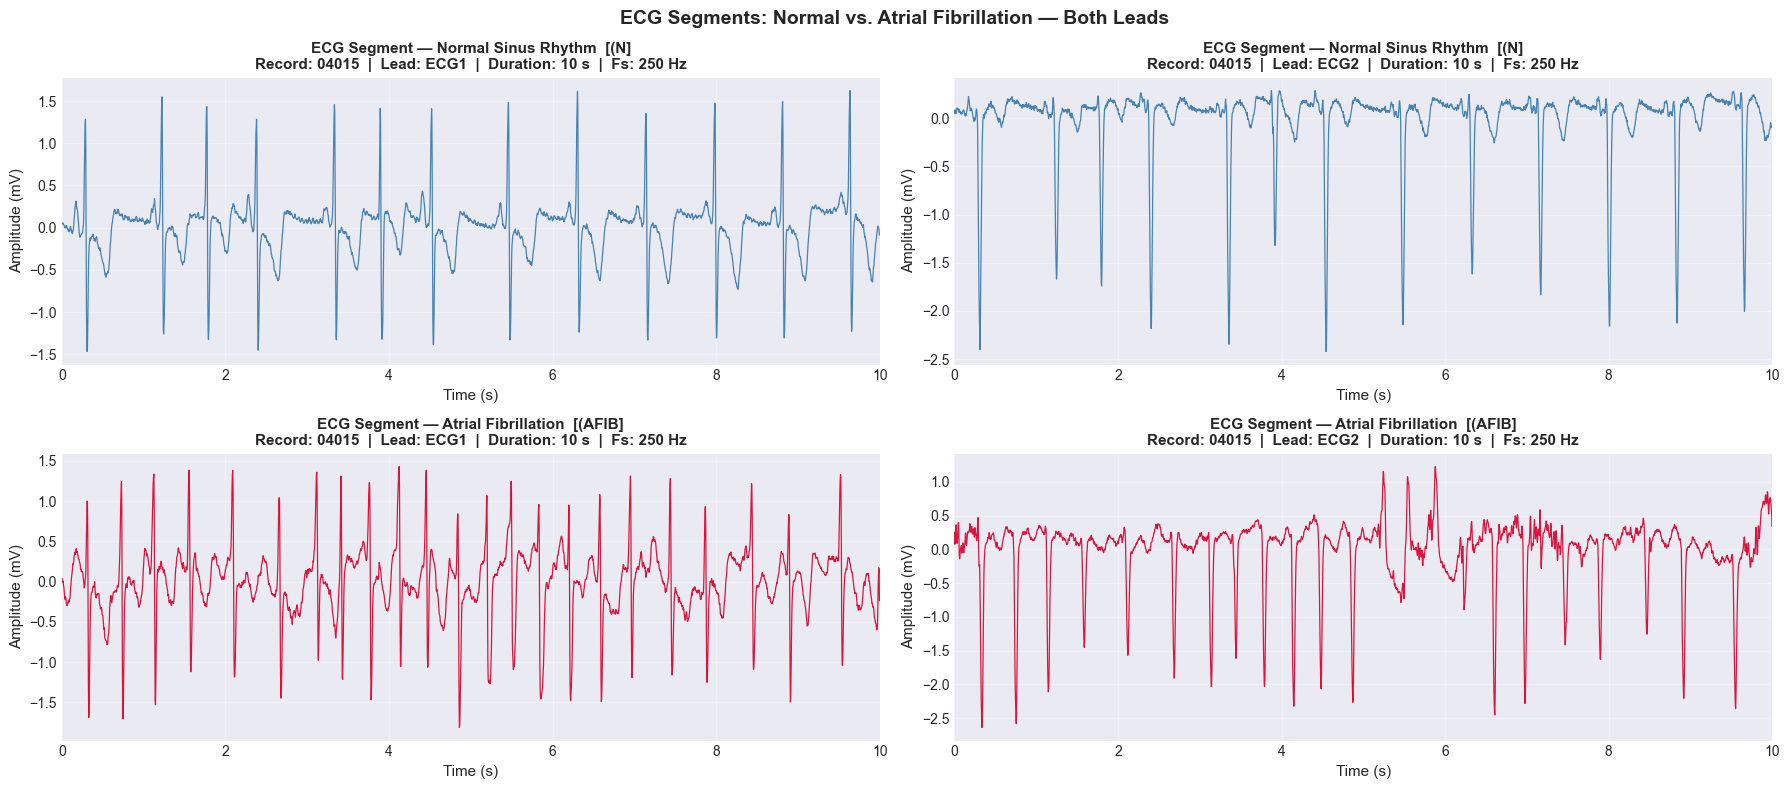

In [12]:
# 4 subplots: rows = Normal / AFIB, columns = Lead 1 / Lead 2
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
fig.suptitle(
    'ECG Segments: Normal vs. Atrial Fibrillation — Both Leads',
    fontsize=14, fontweight='bold'
)

for row, code in enumerate(DESIRED):
    for col, ch in enumerate([0, 1]):
        ax = axes[row, col]
        if code in selected:
            rec_name, samp, fs_val = selected[code]
            plot_ecg_segment(
                rec_name, samp, fs_val,
                rhythm_code=code,
                rhythm_name=NAMES[code],
                duration_sec=SEGMENT_SEC,
                channel=ch,
                ax=ax,
                color=COLORS[code]
            )
        else:
            ax.text(0.5, 0.5, f'No example found for {code}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(NAMES.get(code, code))

plt.tight_layout()
plt.savefig('ecg_segments_both_leads.png', dpi=150, bbox_inches='tight')
plt.show()

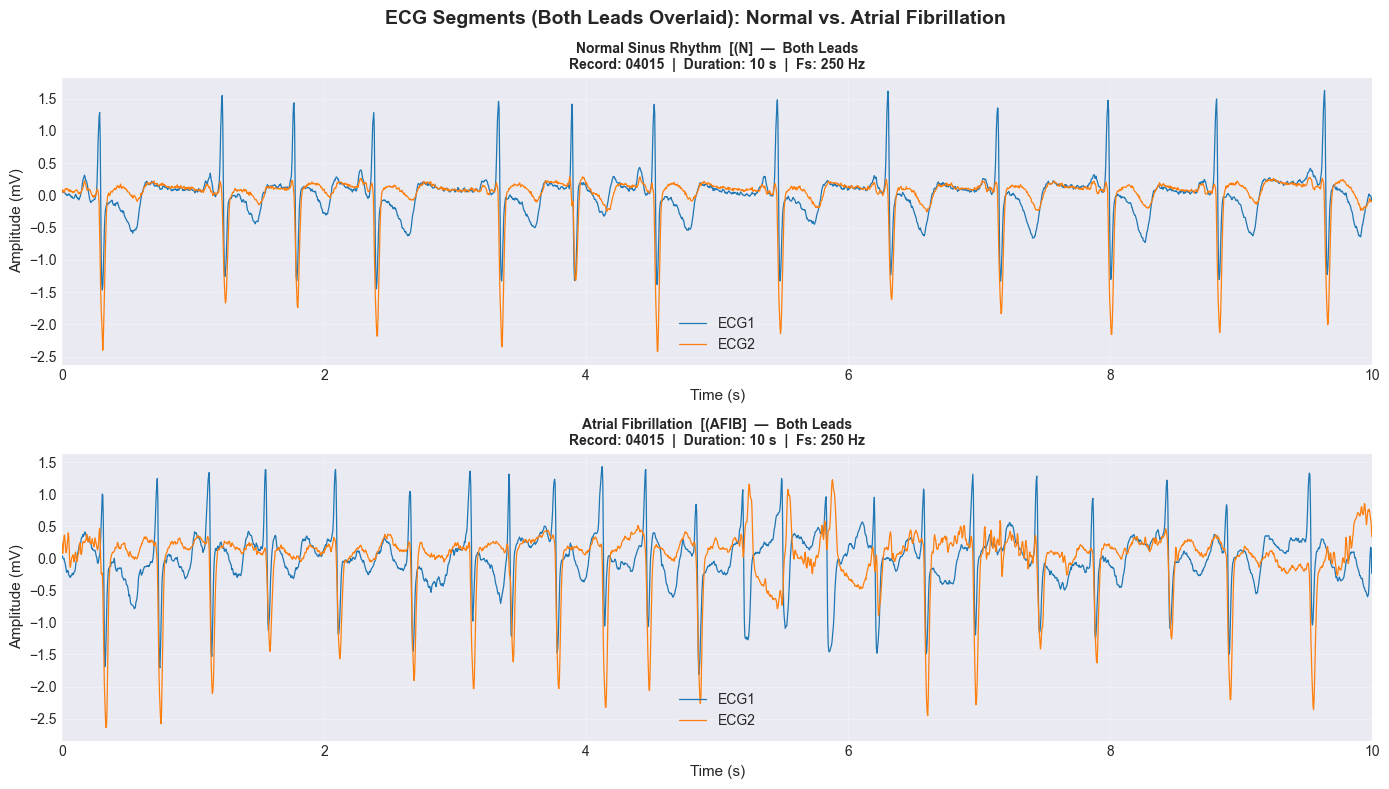

In [13]:
def plot_ecg_both_leads(record_name, sample_start, fs, rhythm_code, rhythm_name,
                        duration_sec=10, ax=None):
    """Plot both leads overlaid on the same axes."""
    n_samples  = int(duration_sec * fs)
    sample_end = sample_start + n_samples

    record = wfdb.rdrecord(
        os.path.join(DATA_DIR, record_name),
        sampfrom=sample_start,
        sampto=sample_end,
        channels=[0, 1]          # read both leads at once
    )

    t = np.arange(n_samples) / fs

    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 3))

    for ch in range(2):
        signal = highpass_filter(record.p_signal[:, ch], fs)
        ax.plot(t, signal, linewidth=0.9, label=record.sig_name[ch])

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Amplitude (mV)', fontsize=11)
    ax.set_title(
        f'{rhythm_name}  [{rhythm_code}]  —  Both Leads\n'
        f'Record: {record_name}  |  Duration: {duration_sec} s  |  Fs: {fs} Hz',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlim([0, duration_sec])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    return ax


# Plot Normal and AFIB each with both leads overlaid
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(
    'ECG Segments (Both Leads Overlaid): Normal vs. Atrial Fibrillation',
    fontsize=14, fontweight='bold'
)

colors_overlay = {'(N': ['steelblue', 'cornflowerblue'],
                  '(AFIB': ['crimson', 'lightcoral']}

for ax, code in zip(axes, DESIRED):
    if code in selected:
        rec_name, samp, fs_val = selected[code]
        plot_ecg_both_leads(
            rec_name, samp, fs_val,
            rhythm_code=code,
            rhythm_name=NAMES[code],
            duration_sec=SEGMENT_SEC,
            ax=ax
        )

plt.tight_layout()
plt.savefig('ecg_both_leads_overlaid.png', dpi=150, bbox_inches='tight')
plt.show()